# 04 · Best ML model per target

In [24]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

from MoleculeACE.benchmark.utils import Data, calc_rmse, calc_cliff_rmse
from MoleculeACE.benchmark.const import Descriptors
from MoleculeACE.models import RF, SVM, GBM, KNN   # only the four algorithms reported in the paper
from sklearn.model_selection import StratifiedKFold, KFold   # cross-validation inside the training set

In [25]:
# Directories
PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "Data"
RESULTS_DIR = PROJECT_ROOT / "Results"
RESULTS_DIR.mkdir(exist_ok=True)

TARGET = "CHEMBL2276"                       #  set the target once here
prepared_file = DATA_DIR / f"{TARGET}_prepared.csv"

# Load using MoleculeACE Data class
data = Data(str(prepared_file))

print("✓ Dataset Loaded Successfully")
print(f"Train size: {len(data.y_train)}")
print(f"Test size: {len(data.y_test)}")

✓ Dataset Loaded Successfully
Train size: 235
Test size: 63


In [26]:
# the 16 descriptor-algorithm combinations reported in the manuscript.
# MLP and the graph, SMILES and token models are not part of the study (and failed in this notebook).
ml_combinations = {
    Descriptors.ECFP: [RF, SVM, GBM, KNN],
    Descriptors.MACCS: [RF, SVM, GBM, KNN],
    Descriptors.PHYSCHEM: [RF, SVM, GBM, KNN],
    Descriptors.WHIM: [RF, SVM, GBM, KNN],
    }

In [27]:
# exact values used for every target, with fixed random seeds.
# Source: MoleculeACE v3.0.0, Data/configures/benchmark/CHEMBL204_Ki/*.yml (its optimised thrombin settings).
SEED = 42
N_FOLDS = 5

custom_hyperparameters = {

    # ---------------- RF ----------------
    "RF_ECFP": {"n_estimators": 1000, "random_state": SEED},
    "RF_MACCS": {"n_estimators": 500, "random_state": SEED},
    "RF_PHYSCHEM": {"n_estimators": 500, "random_state": SEED},
    "RF_WHIM": {"n_estimators": 500, "random_state": SEED},

    # ---------------- GBM ----------------
    "GBM_ECFP": {
        "learning_rate": 0.1,
        "max_depth": 5,
        "max_features": "sqrt",
        "max_leaf_nodes": None,
        "min_samples_leaf": 1,
        "min_samples_split": 2,
        "random_state": SEED,
        "n_estimators": 400
    },
    "GBM_MACCS": {
        "learning_rate": 0.1,
        "max_depth": 6,
        "max_features": "sqrt",
        "max_leaf_nodes": None,
        "min_samples_leaf": 1,
        "min_samples_split": 2,
        "random_state": SEED,
        "n_estimators": 400
    },
    "GBM_PHYSCHEM": {
        "learning_rate": 0.1,
        "max_depth": 6,
        "max_features": "sqrt",
        "max_leaf_nodes": None,
        "min_samples_leaf": 1,
        "min_samples_split": 2,
        "random_state": SEED,
        "n_estimators": 200
    },
    "GBM_WHIM": {
        "learning_rate": 0.1,
        "max_depth": 6,
        "max_features": "sqrt",
        "max_leaf_nodes": None,
        "min_samples_leaf": 1,
        "min_samples_split": 2,
        "random_state": SEED,
        "n_estimators": 200
    },

    # ---------------- SVM ----------------
    "SVM_ECFP": {"C": 10, "epsilon": 0.1, "gamma": 0.01, "kernel": "rbf"},
    "SVM_MACCS": {"C": 10, "epsilon": 0.1, "gamma": 0.1, "kernel": "rbf"},
    "SVM_PHYSCHEM": {"C": 100, "epsilon": 0.1, "gamma": 0.1, "kernel": "rbf"},
    "SVM_WHIM": {"C": 1, "epsilon": 0.1, "gamma": 0.01, "kernel": "rbf"},

    # ---------------- KNN ----------------
    "KNN_ECFP": {"metric": "euclidean", "n_neighbors": 5, "weights": "distance"},
    "KNN_MACCS": {"metric": "euclidean", "n_neighbors": 3, "weights": "distance"},
    "KNN_PHYSCHEM": {"metric": "euclidean", "n_neighbors": 11, "weights": "distance"},
    "KNN_WHIM": {"metric": "euclidean", "n_neighbors": 11, "weights": "distance"},
}

In [28]:
# the combination is now chosen by 5-fold cross-validation INSIDE the training set.
# Out-of-fold predictions are pooled and one cliff RMSE is computed from them (CV_Cliff_RMSE). The test set
# is used only to report the result (RMSE, Cliff_RMSE); it is never used to choose the model.
# Same procedure as rerun_with_validation.py, so the two give identical results.

def out_of_fold_predictions(model_class, hyperparams, x, y, cliff, n_folds=N_FOLDS, seed=SEED):
    y = np.asarray(y, dtype=float)
    cliff = np.asarray(cliff).astype(int)
    oof = np.full(len(y), np.nan)
    stratified = cliff.sum() >= n_folds and (len(cliff) - cliff.sum()) >= n_folds
    if stratified:
        folds = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed).split(np.zeros(len(y)), cliff)
    else:
        folds = KFold(n_splits=n_folds, shuffle=True, random_state=seed).split(np.zeros(len(y)))
    for tr_idx, va_idx in folds:
        m = model_class(**hyperparams)
        m.train(x[tr_idx], y[tr_idx])
        oof[va_idx] = m.predict(x[va_idx])
    return oof


results = []
predictions = []   # REVISION (comment 8): every test prediction, for bootstrap confidence intervals

print("="*70)
print("STARTING ML BENCHMARK")
print("="*70)

for descriptor, models in ml_combinations.items():

    print(f"\nDescriptor: {descriptor.name}")
    try:                                       # REVISION: a descriptor that cannot be computed is skipped
        data.featurize_data(descriptor)        # (e.g. WHIM for one CHEMBL233 compound) instead of stopping
    except Exception as e:
        print(f"  ✗ Descriptor skipped: {e}")
        continue
    x_train, x_test = np.asarray(data.x_train), np.asarray(data.x_test)

    for model_class in models:

        model_name = model_class.__name__
        print(f"  Training {model_name}...")

        try:
            key = f"{model_name}_{descriptor.name}"
            hyperparams = custom_hyperparameters.get(key, {}).copy()

            # cross-validation inside the training set (used for model selection)
            oof = out_of_fold_predictions(model_class, hyperparams, x_train, data.y_train, data.cliff_mols_train)
            cv_rmse = calc_rmse(data.y_train, oof)
            cv_cliff_rmse = calc_cliff_rmse(y_test_pred=oof, y_test=data.y_train,
                                            cliff_mols_test=data.cliff_mols_train)

            # refit on the full training set, score once on the test set (used for reporting only)
            model = model_class(**hyperparams)
            model.train(x_train, data.y_train)
            y_pred = model.predict(x_test)

            rmse = calc_rmse(data.y_test, y_pred)
            cliff_rmse = calc_cliff_rmse(
                y_test_pred=y_pred,
                y_test=data.y_test,
                cliff_mols_test=data.cliff_mols_test
            )

            results.append({
                "Descriptor": descriptor.name,
                "Model": model_name,
                "CV_RMSE": cv_rmse,
                "CV_Cliff_RMSE": cv_cliff_rmse,
                "RMSE": rmse,
                "Cliff_RMSE": cliff_rmse
            })
            predictions.append(pd.DataFrame({
                "target": TARGET, "descriptor": descriptor.name, "model": model_name,
                "smiles": data.smiles_test, "y_true": data.y_test, "y_pred": y_pred,
                "cliff_mol": data.cliff_mols_test}))

            print(f"    ✓ CV Cliff RMSE: {cv_cliff_rmse:.4f} | test RMSE: {rmse:.4f} | test Cliff RMSE: {cliff_rmse:.4f}")

        except Exception as e:
            print(f"    ✗ Failed: {e}")

STARTING ML BENCHMARK

Descriptor: ECFP
  Training RF...
    ✓ CV Cliff RMSE: 0.6893 | test RMSE: 0.7745 | test Cliff RMSE: 1.0586
  Training SVM...
    ✓ CV Cliff RMSE: 0.7138 | test RMSE: 0.7732 | test Cliff RMSE: 0.9669
  Training GBM...
    ✓ CV Cliff RMSE: 0.7995 | test RMSE: 0.8213 | test Cliff RMSE: 1.0336
  Training KNN...
    ✓ CV Cliff RMSE: 0.7423 | test RMSE: 0.8891 | test Cliff RMSE: 0.8218

Descriptor: MACCS
  Training RF...
    ✓ CV Cliff RMSE: 0.7436 | test RMSE: 0.8275 | test Cliff RMSE: 1.1430
  Training SVM...
    ✓ CV Cliff RMSE: 0.8399 | test RMSE: 0.8246 | test Cliff RMSE: 1.0843
  Training GBM...
    ✓ CV Cliff RMSE: 0.8126 | test RMSE: 0.7939 | test Cliff RMSE: 1.1455
  Training KNN...
    ✓ CV Cliff RMSE: 0.8439 | test RMSE: 0.9481 | test Cliff RMSE: 1.0066

Descriptor: PHYSCHEM
  Training RF...
    ✓ CV Cliff RMSE: 0.8332 | test RMSE: 0.7646 | test Cliff RMSE: 0.8749
  Training SVM...
    ✓ CV Cliff RMSE: 0.8156 | test RMSE: 0.9011 | test Cliff RMSE: 1.1445
  

100%|██████████| 63/63 [00:05<00:00, 12.08it/s]


  Training RF...
    ✓ CV Cliff RMSE: 0.8368 | test RMSE: 0.8159 | test Cliff RMSE: 0.9114
  Training SVM...
    ✓ CV Cliff RMSE: 0.8889 | test RMSE: 0.8835 | test Cliff RMSE: 0.9481
  Training GBM...
    ✓ CV Cliff RMSE: 0.8493 | test RMSE: 0.8483 | test Cliff RMSE: 0.9063
  Training KNN...
    ✓ CV Cliff RMSE: 0.8466 | test RMSE: 0.8555 | test Cliff RMSE: 0.7707


In [29]:
results_df = pd.DataFrame(results)
# REVISION (comment 2): rank by the cross-validated cliff RMSE, not by the test-set value
results_df = results_df.sort_values("CV_Cliff_RMSE").reset_index(drop=True)
results_df["Rank"] = range(1, len(results_df) + 1)

print("\n" + "="*70)
print(f"BEST ML MODELS FOR {TARGET} (selected by cross-validation)")
print("="*70)
print(results_df)

best_model = results_df.iloc[0]

print("\n" + "="*70)
print(f"🏆 BEST MODEL FOR {TARGET}")
print("="*70)
print(f"Descriptor: {best_model['Descriptor']}")
print(f"Model: {best_model['Model']}")
print(f"CV Cliff RMSE (selection): {best_model['CV_Cliff_RMSE']:.4f}")
print(f"Test RMSE: {best_model['RMSE']:.4f}")
print(f"Test Cliff RMSE: {best_model['Cliff_RMSE']:.4f}")


BEST ML MODELS FOR CHEMBL2276 (selected by cross-validation)
   Descriptor Model   CV_RMSE  CV_Cliff_RMSE      RMSE  Cliff_RMSE  Rank
0        ECFP    RF  0.699314       0.689316  0.774451    1.058648     1
1        ECFP   SVM  0.691979       0.713823  0.773193    0.966886     2
2        ECFP   KNN  0.784586       0.742272  0.889064    0.821835     3
3       MACCS    RF  0.726136       0.743575  0.827533    1.142962     4
4    PHYSCHEM   KNN  0.687044       0.755603  0.816369    0.903332     5
5        ECFP   GBM  0.724568       0.799474  0.821255    1.033553     6
6       MACCS   GBM  0.754095       0.812639  0.793903    1.145474     7
7    PHYSCHEM   SVM  0.794450       0.815593  0.901065    1.144518     8
8    PHYSCHEM   GBM  0.778906       0.821423  0.734926    0.715683     9
9    PHYSCHEM    RF  0.741645       0.833200  0.764620    0.874865    10
10       WHIM    RF  0.787729       0.836827  0.815889    0.911397    11
11      MACCS   SVM  0.767363       0.839852  0.824623    1.08

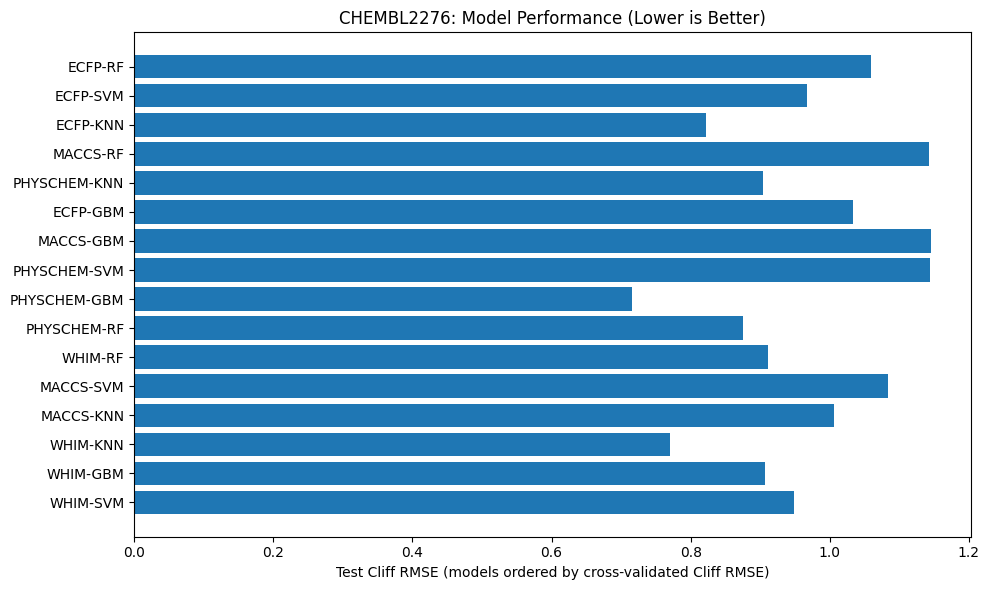

In [30]:
results_df.to_csv(RESULTS_DIR / f"ML_model_{TARGET}.csv", index=False)
pd.concat(predictions, ignore_index=True).to_csv(RESULTS_DIR / f"test_predictions_{TARGET}.csv", index=False)   # REVISION
plt.figure(figsize=(10, 6))
plt.barh(
    results_df["Descriptor"] + "-" + results_df["Model"],
    results_df["Cliff_RMSE"]
)
plt.xlabel("Test Cliff RMSE (models ordered by cross-validated Cliff RMSE)")   # REVISION
plt.title(f"{TARGET}: Model Performance (Lower is Better)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()